In [97]:
import pandas as pd
import os

DATA_DIR = '/home/nakamuraroi/kumagai/work/dataset/PatentsViewBulkData'
os.makedirs(DATA_DIR, exist_ok=True)

FILES = {
    "patent": os.path.join(DATA_DIR, "g_patent.tsv"),
    "inventor": os.path.join(DATA_DIR, "g_inventor_disambiguated.tsv"),
    "cpc": os.path.join(DATA_DIR, "g_cpc_current.tsv")
}

In [73]:
import pandas as pd
import os

# データのディレクトリ（ご自身の環境に合わせて変更してください）
patent_file = os.path.join(DATA_DIR, "g_patent.tsv")

# 最初の1行だけ読み込む
try:
    df_head = pd.read_csv(patent_file, sep='\t', nrows=2)
    print("【g_patent.tsv に存在する列名】")
    print(df_head.columns.tolist())
except Exception as e:
    print(f"ファイル読み込みエラー: {e}")

【g_patent.tsv に存在する列名】
['patent_id', 'patent_type', 'patent_date', 'patent_title', 'wipo_kind', 'num_claims', 'withdrawn', 'filename']


In [74]:
df_head

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature detection,B2,20,0,ipg180619.xml
1,10000001,utility,2018-06-19,Injection molding machine and mold thickness control method,B2,12,0,ipg180619.xml


In [75]:
import pandas as pd
import os

# データのディレクトリ（ご自身の環境に合わせて変更してください）
patent_file = os.path.join(DATA_DIR, "g_inventor_disambiguated.tsv")

# 最初の1行だけ読み込む
try:
    df_head = pd.read_csv(patent_file, sep='\t', nrows=1)
    print("【g_inventor_disambiguated.tsv に存在する列名】")
    print(df_head.columns.tolist())
except Exception as e:
    print(f"ファイル読み込みエラー: {e}")

【g_inventor_disambiguated.tsv に存在する列名】
['patent_id', 'inventor_sequence', 'inventor_id', 'disambig_inventor_name_first', 'disambig_inventor_name_last', 'gender_code', 'location_id']


In [76]:
df_head

,patent_id,inventor_sequence,inventor_id,disambig_inventor_name_first,disambig_inventor_name_last,gender_code,location_id
0,D1006496,0,fl:we_ln:jiang-160,Wenjing,Jiang,F,9d072d42-49af-11ed-9879-1234bde3cd05


In [77]:
import pandas as pd
import os

# データのディレクトリ（ご自身の環境に合わせて変更してください）
patent_file = os.path.join(DATA_DIR, "g_cpc_current.tsv")

# 最初の1行だけ読み込む
try:
    df_head = pd.read_csv(patent_file, sep='\t', nrows=1)
    print("【g_cpc_current.tsv に存在する列名】")
    print(df_head.columns.tolist())
except Exception as e:
    print(f"ファイル読み込みエラー: {e}")

【g_cpc_current.tsv に存在する列名】
['patent_id', 'cpc_sequence', 'cpc_section', 'cpc_class', 'cpc_subclass', 'cpc_group', 'cpc_type']


In [78]:
df_head

,patent_id,cpc_sequence,cpc_section,cpc_class,cpc_subclass,cpc_group,cpc_type
0,3950000,0,A,A63,A63C,A63C9/001,inventional


In [68]:
def create_dataset():
    # ---------------------------------------------------------
    # 1. トピック（CPC）の読み込み
    # ---------------------------------------------------------
    print("Loading CPC Data...")
    # 'g_cpc_current.tsv' は巨大なので、必要な列だけ読みます
    # cpc_group: 技術カテゴリ（例: G06N）
    cols_cpc = ['patent_id', 'cpc_group']
    
    # メモリ節約のため、とりあえず 'G06N' (AI関連) を含む行だけ抽出する例
    # ※ 本番では必要なカテゴリに合わせて調整してください
    chunks = []
    for chunk in pd.read_csv(FILES["cpc"], sep='\t', usecols=cols_cpc, chunksize=1000000, dtype={'patent_id': str, 'cpc_group': str}):
        # データ型変換（エラー回避）
        chunk['cpc_group'] = chunk['cpc_group'].astype(str)
        # フィルタリング
        matched = chunk[chunk['cpc_group'].str.startswith('E04')] # E04 (建築関連)
        chunks.append(matched)
    
    df_cpc = pd.concat(chunks)
    target_patent_ids = df_cpc['patent_id'].unique()
    print(f"  -> Target Patents found: {len(target_patent_ids)}")

    # ---------------------------------------------------------
    # 2. 特許（日付）の読み込み
    # ---------------------------------------------------------
    print("Loading Patent Dates...")
    # 'g_patent.tsv' から patent_id と date を読み込む
    cols_patent = ['patent_id', 'patent_date'] # date列が日付

    # chunksizeを使って読み込みながらフィルタリング（メモリ節約）
    patent_chunks = []
    for chunk in pd.read_csv(FILES["patent"], sep='\t', usecols=cols_patent, 
                             chunksize=1000000, 
                             dtype={'patent_id': str, 'patent_date': str}): # ここ重要
        
        # ターゲットに含まれるIDだけ残す
        matched = chunk[chunk['patent_id'].isin(target_patent_ids)]
        patent_chunks.append(matched)
        
    df_patent = pd.concat(patent_chunks)
    df_patent['patent_date'] = pd.to_datetime(df_patent['patent_date'], errors='coerce')
    
    # 日付が取れなかったデータは削除
    df_patent = df_patent.dropna(subset=['patent_date'])
    
    print(f"  -> Patents with dates found: {len(df_patent)}")

    # ---------------------------------------------------------
    # 3. 発明者（Disambiguated）の読み込み
    # ---------------------------------------------------------
    print("Loading Inventors...")
    # 'g_inventor_disambiguated.tsv'
    cols_inv = ['patent_id', 'inventor_id']
    df_inv = pd.read_csv(FILES["inventor"], sep='\t', usecols=cols_inv)
    
    # ターゲットに含まれる特許のみ残す
    df_inv = df_inv[df_inv['patent_id'].isin(target_patent_ids)]

    # ---------------------------------------------------------
    # 4. 結合 (Merge)
    # ---------------------------------------------------------
    print("Merging Tables...")
    # Patent + Inventor
    df_merged = pd.merge(df_patent, df_inv, on='patent_id')
    # + CPC
    df_final = pd.merge(df_merged, df_cpc, on='patent_id')
    
    # ---------------------------------------------------------
    # 5. 整形
    # ---------------------------------------------------------
    # 必要な列: [Time, User(Inventor), Item(Topic)]
    dataset = df_final[['patent_date', 'inventor_id', 'cpc_group']].rename(
        columns={'patent_date': 'ts', 'inventor_id': 'u', 'cpc_group': 'i'}
    )
    
    # 時系列順にソート（Neural ODEには必須）
    dataset = dataset.sort_values('ts')
    
    print("Done!")
    print(dataset.head())
    return dataset


In [79]:
# 実行
if __name__ == "__main__":
    df = create_dataset()
    df.to_csv(DATA_DIR + "/bipartite_events.csv", index=False)

Loading CPC Data...
  -> Target Patents found: 75987
Loading Patent Dates...
  -> Patents with dates found: 75987
Loading Inventors...
Merging Tables...
Done!
               ts                          u             i
161505 1976-01-06         fl:ag_ln:nilsson-2      E04H3/08
161486 1976-01-06  az428lzdv14gqt1vemlf210t5  E04D2015/045
161487 1976-01-06  m9sbbg9qes39zdzoducg1acd8  E04D2015/045
161488 1976-01-06           fl:jo_ln:wolf-42    E04G11/062
161489 1976-01-06           fl:jo_ln:wolf-42      E04G9/06


In [80]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder

def preprocess_and_split():
    # 1. データの読み込み
    print("Loading csv...")
    df = pd.read_csv(DATA_DIR + "/bipartite_events.csv")
    
    # 2. IDのエンコーディング (文字列 -> 0から始まる整数)
    # Neural Networkは文字列を扱えないため、IDを数値に変換します
    print("Encoding IDs...")
    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()
    
    df['u_idx'] = user_encoder.fit_transform(df['u'])
    df['i_idx'] = item_encoder.fit_transform(df['i'])
    
    num_users = len(user_encoder.classes_)
    num_items = len(item_encoder.classes_)
    
    print(f"Num Users: {num_users}, Num Topics: {num_items}")

    # 3. 時間の正規化 (Normalization)
    # Neural ODEは大きな数値（Unix timestampなど）を入れると計算が不安定になります。
    # 開始日を0、終了日を100程度に収めるのがコツです。
    print("Normalizing Time...")
    df['ts'] = pd.to_datetime(df['ts'])
    t_start = df['ts'].min()
    # 日数に変換
    df['time_days'] = (df['ts'] - t_start).dt.total_seconds() / (24 * 3600)
    # 最大値を10.0くらいにスケーリング (ODEの学習が安定します)
    max_time = df['time_days'].max()
    df['time_norm'] = (df['time_days'] / max_time) * 10.0
    
    # 4. データの分割 (Chronological Split)
    print("Splitting Data...")
    
    # 時間でソート（念のため）
    df = df.sort_values('time_norm')

    # 全行数
    n_total = len(df)

    train_end_idx = int(n_total * 0.70)
    val_end_idx = int(n_total * 0.85) 
    
    # ilocを使って行番号で分割
    data_train = df.iloc[:train_end_idx]
    data_val   = df.iloc[train_end_idx:val_end_idx]
    data_test  = df.iloc[val_end_idx:]
    
    print(f"Train: {len(data_train)} ({len(data_train)/n_total:.1%})")
    print(f"Val:   {len(data_val)} ({len(data_val)/n_total:.1%})")
    print(f"Test:  {len(data_test)} ({len(data_test)/n_total:.1%})")

    # 5. 保存
    save_path = os.path.join(DATA_DIR, "processed_data.pt")

    processed_data = {
        # データ本体 (Tensor化)
        'train': {
            'u': torch.LongTensor(data_train['u_idx'].values),
            'i': torch.LongTensor(data_train['i_idx'].values),
            't': torch.FloatTensor(data_train['time_norm'].values)
        },
        'val': {
            'u': torch.LongTensor(data_val['u_idx'].values),
            'i': torch.LongTensor(data_val['i_idx'].values),
            't': torch.FloatTensor(data_val['time_norm'].values)
        },
        'test': {
            'u': torch.LongTensor(data_test['u_idx'].values),
            'i': torch.LongTensor(data_test['i_idx'].values),
            't': torch.FloatTensor(data_test['time_norm'].values)
        },
        # メタデータ (モデル構築時に必要)
        'num_users': num_users,
        'num_items': num_items,
        't_max_days': max_time # 元の日数に戻す用
    }
    
    torch.save(processed_data, save_path)
    print(f"Saved to '{save_path}'. Ready for training!")

if __name__ == "__main__":
    preprocess_and_split()

Loading csv...
Encoding IDs...
Num Users: 72763, Num Topics: 2553
Normalizing Time...
Splitting Data...
Train: 291617 (70.0%)
Val:   62490 (15.0%)
Test:  62490 (15.0%)
Saved to '/home/nakamuraroi/kumagai/work/dataset/PatentsViewBulkData/processed_data.pt'. Ready for training!


In [81]:
import torch

def inspect_pt_file():
    print("Loading processed_data.pt ...")
    try:
        data = torch.load( DATA_DIR + "/processed_data.pt")
    except FileNotFoundError:
        print("Error: processed_data.pt が見つかりません。さっきのコードを実行しましたか？")
        return

    # 1. 全体のキーを確認
    print("\n=== 1. Top-Level Keys ===")
    print(data.keys())

    # 2. メタデータの確認
    print("\n=== 2. Metadata ===")
    print(f"Num Inventors (Users): {data['num_users']}")
    print(f"Num Topics (Items):    {data['num_items']}")
    print(f"Max Original Days:     {data['t_max_days']:.2f} days")

    # 3. 学習データ(Train)の中身確認
    print("\n=== 3. Train Data Inspection ===")
    train_data = data['train']
    
    # テンソルのサイズ確認
    u = train_data['u']
    i = train_data['i']
    t = train_data['t']
    
    print(f"Count: {len(u)} interactions")
    print(f"Shapes -> User: {u.shape}, Item: {i.shape}, Time: {t.shape}")
    
    # データ型とサンプル値の確認
    print("\n--- Sample Values (First 5) ---")
    print(f"Users (Int):   {u[:5].tolist()}")
    print(f"Items (Int):   {i[:5].tolist()}")
    print(f"Time (Float):  {t[:5].tolist()}") # 0.0 ~ 10.0 になっていればOK

    # 4. テストデータ(Test)の中身確認
    print("\n=== 4. Test Data Inspection ===")
    test_data = data['test']
    print(f"Count: {len(test_data['u'])} interactions")
    
    # 時間順序の確認（Trainの最後よりTestの最初が未来であるべき）
    print("\n--- Time Order Check ---")
    print(f"Train Last Time: {t[-1].item():.4f}")
    print(f"Test First Time: {test_data['t'][0].item():.4f}")
    
    if t[-1].item() <= test_data['t'][0].item():
        print("✅ OK: TrainとTestが正しく時間順で分割されています。")
    else:
        print("⚠️ Warning: 時間順が逆転している可能性があります！")

if __name__ == "__main__":
    inspect_pt_file()

Loading processed_data.pt ...

=== 1. Top-Level Keys ===
dict_keys(['train', 'val', 'test', 'num_users', 'num_items', 't_max_days'])

=== 2. Metadata ===
Num Inventors (Users): 72763
Num Topics (Items):    2553
Max Original Days:     18067.00 days

=== 3. Train Data Inspection ===
Count: 291617 interactions
Shapes -> User: torch.Size([291617]), Item: torch.Size([291617]), Time: torch.Size([291617])

--- Sample Values (First 5) ---
Users (Int):   [3385, 70416, 54751, 54751, 24422]
Items (Int):   [2395, 1646, 1573, 690, 935]
Time (Float):  [0.0, 0.0, 0.0, 0.0, 0.0]

=== 4. Test Data Inspection ===
Count: 62490 interactions

--- Time Order Check ---
Train Last Time: 8.8958
Test First Time: 9.4305
✅ OK: TrainとTestが正しく時間順で分割されています。


/tmp/ipykernel_651305/347883812.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load( DATA_DIR + "/processed_data.pt")


In [82]:
data = torch.load( DATA_DIR + "/processed_data.pt")
data

/tmp/ipykernel_651305/1549830294.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load( DATA_DIR + "/processed_data.pt")


{'train': {'u': tensor([ 3385, 70416, 54751,  ..., 49116, 49116, 49116]),
  'i': tensor([2395, 1646, 1573,  ..., 1506, 1508, 1711]),
  't': tensor([0.0000, 0.0000, 0.0000,  ..., 8.8958, 8.8958, 8.8958])},
 'val': {'u': tensor([49116, 49116,  5198,  ..., 29214, 58927, 29214]),
  'i': tensor([1712, 1713, 1461,  ..., 1671,  222, 1704]),
  't': tensor([8.8958, 8.8958, 8.8958,  ..., 9.4305, 9.4305, 9.4305])},
 'test': {'u': tensor([44383, 44383, 55885,  ..., 47651, 20320, 38687]),
  'i': tensor([ 222,  689, 2026,  ..., 2248,  266, 2248]),
  't': tensor([ 9.4305,  9.4305,  9.4305,  ..., 10.0000, 10.0000, 10.0000])},
 'num_users': 72763,
 'num_items': 2553,
 't_max_days': 18067.0}

In [94]:
import pandas as pd
import os

def check_item_contents():
    print("Loading original csv...")
    csv_path = os.path.join(DATA_DIR, "bipartite_events.csv")
    if not os.path.exists(csv_path):
        print("Error: bipartite_events.csv が見つかりません。")
        return

    df = pd.read_csv(csv_path)
    
    # 文字列として扱う
    df['i'] = df['i'].astype(str)
    
    # 1. LabelEncoderと同じロジックでIDを復元
    # (ユニークな値をアルファベット順にソートすると、IDと一致します)
    unique_topics = sorted(df['i'].unique())
    
    # ID -> トピック名の辞書
    id_to_topic = {idx: name for idx, name in enumerate(unique_topics)}
    
    # 2. 出現回数をカウント（どの技術がメインなのか確認）
    topic_counts = df['i'].value_counts()
    
    print("\n" + "="*50)
    print("   ITEM (TOPIC) MAPPING LIST")
    print("="*50)
    print(f"{'ID':<4} | {'Topic Name (CPC)':<12} | {'Count':<8} | {'Note'}")
    print("-" * 50)
    
    # ここではID順に全件表示します（83件なら表示可能）
    for idx, name in id_to_topic.items():
        count = topic_counts.get(name, 0)
        # E04 (建築系) は目立つようにマーク
        mark = "★" if "E04" in name else "" 
        print(f"{idx:<5} | {name:<15} | {count:<8} {mark}")

    print("-" * 50)
    print(f"Total Items: {len(unique_topics)}")

if __name__ == "__main__":
    check_item_contents()

Loading original csv...

   ITEM (TOPIC) MAPPING LIST
ID   | Topic Name (CPC) | Count    | Note
--------------------------------------------------
0     | E04B1/00        | 154      ★
1     | E04B1/0007      | 362      ★
2     | E04B1/0015      | 34       ★
3     | E04B1/0023      | 81       ★
4     | E04B1/003       | 522      ★
5     | E04B1/0038      | 56       ★
6     | E04B1/0046      | 151      ★
7     | E04B1/02        | 112      ★
8     | E04B1/04        | 412      ★
9     | E04B1/043       | 319      ★
10    | E04B1/046       | 41       ★
11    | E04B1/06        | 50       ★
12    | E04B1/08        | 272      ★
13    | E04B1/10        | 314      ★
14    | E04B1/12        | 173      ★
15    | E04B1/14        | 513      ★
16    | E04B1/16        | 253      ★
17    | E04B1/161       | 245      ★
18    | E04B1/162       | 15       ★
19    | E04B1/163       | 23       ★
20    | E04B1/164       | 49       ★
21    | E04B1/165       | 170      ★
22    | E04B1/166       | 54       ★
23

Loading data...
Converting 'ts' column to datetime...

データ期間: 1976年 〜 2025年
表示対象: 上位 25 件の技術 (CPCコード)


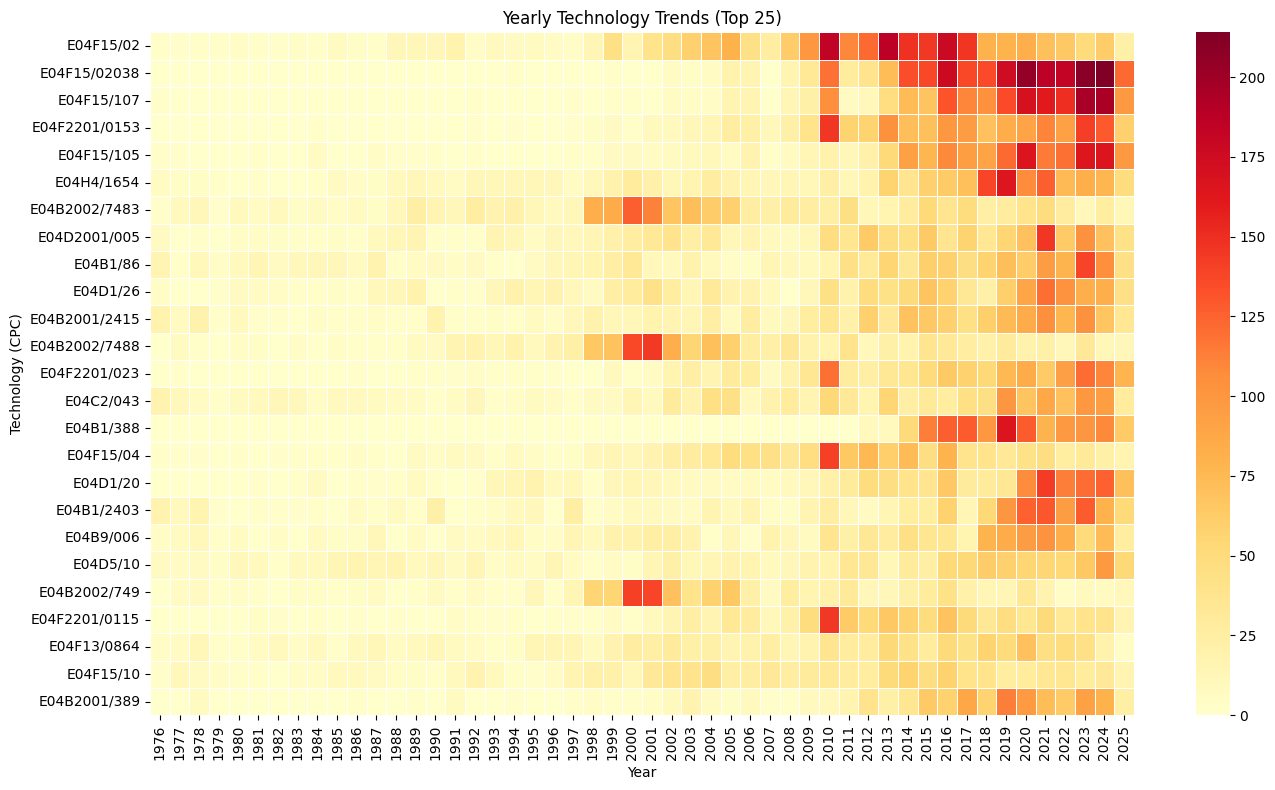

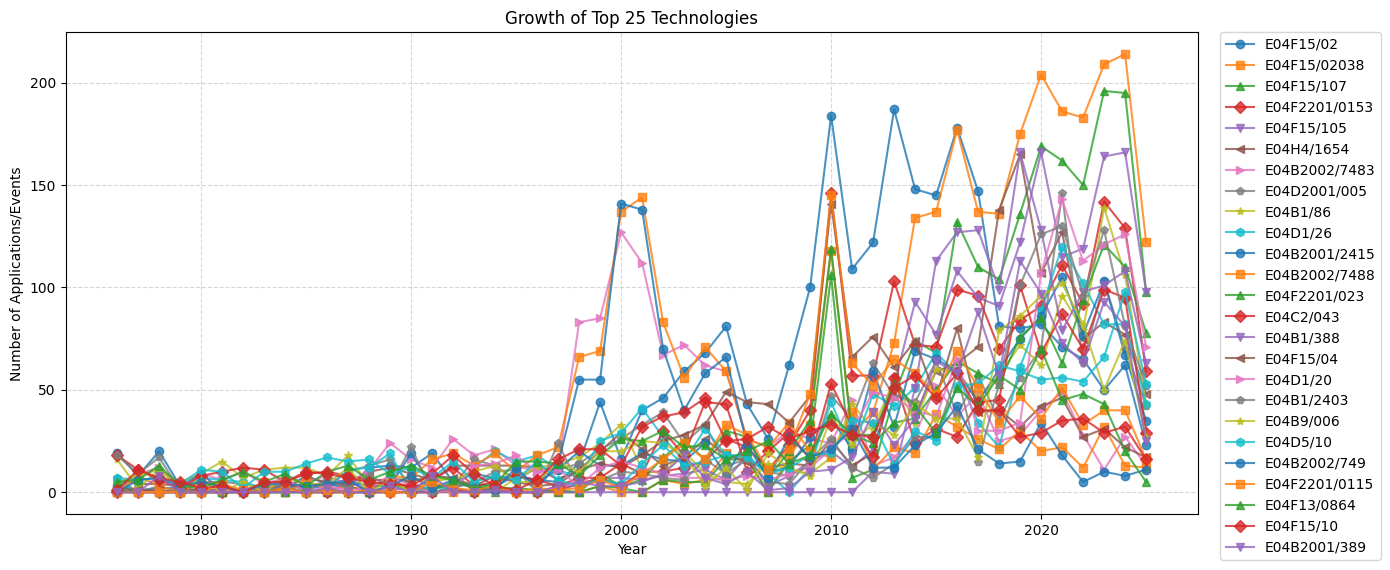

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ==========================================
# 設定
# ==========================================
DATA_DIR = '/home/nakamuraroi/kumagai/work/dataset/PatentsViewBulkData'
CSV_NAME = "bipartite_events.csv" # ファイル名
TOP_N = 25                 # 上位何個の技術を表示するか

def analyze_yearly_trends_v2():
    csv_path = os.path.join(DATA_DIR, CSV_NAME)
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} が見つかりません。")
        return

    print("Loading data...")
    # csv読み込み
    df = pd.read_csv(csv_path)

    # -------------------------------------------------------
    # 1. 前処理: 日付文字列を「年」に変換
    # -------------------------------------------------------
    print("Converting 'ts' column to datetime...")
    
    # エラー回避: 日付として解釈できないデータは NaT (Not a Time) にする
    df['ts'] = pd.to_datetime(df['ts'], errors='coerce')
    
    # 日付変換に失敗した行（空文字など）があれば削除
    df = df.dropna(subset=['ts'])

    # 年を抽出して新しい列 'year' を作る
    df['year'] = df['ts'].dt.year

    # 技術ID (i列) を文字列型にする
    df['i'] = df['i'].astype(str)

    # -------------------------------------------------------
    # 2. 集計: 年 × 技術 のクロス集計
    # -------------------------------------------------------
    # 行=年, 列=技術ID, 値=件数
    trend_matrix = df.pivot_table(index='year', columns='i', aggfunc='size', fill_value=0)
    
    # 全期間での合計件数が多い順にソートし、上位 TOP_N 個だけを抽出
    top_items = trend_matrix.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
    trend_top = trend_matrix[top_items]

    print(f"\nデータ期間: {df['year'].min()}年 〜 {df['year'].max()}年")
    print(f"表示対象: 上位 {TOP_N} 件の技術 (CPCコード)")

    # -------------------------------------------------------
    # 3. 可視化: ヒートマップ (濃淡でブームを把握)
    # -------------------------------------------------------
    plt.figure(figsize=(14, 8))
    # cmap="YlOrRd" は 黄色(少ない) -> 赤(多い) のグラデーション
    sns.heatmap(trend_top.T, cmap="YlOrRd", annot=False, linewidths=.5)
    
    plt.title(f"Yearly Technology Trends (Top {TOP_N})")
    plt.xlabel("Year")
    plt.ylabel("Technology (CPC)")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # 4. 可視化: ラインチャート (推移を比較)
    # -------------------------------------------------------
    plt.figure(figsize=(14, 6))
    
    # 線の種類やマーカーを変えて見やすくする
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    for idx, column in enumerate(trend_top.columns):
        marker = markers[idx % len(markers)] # マーカーを循環させる
        plt.plot(trend_top.index, trend_top[column], marker=marker, label=column, alpha=0.8)
    
    plt.title(f"Growth of Top {TOP_N} Technologies")
    plt.xlabel("Year")
    plt.ylabel("Number of Applications/Events")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_yearly_trends_v2()

In [130]:
# [Cell 1] 環境設定とライブラリのインポート

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

# PyTorch関連
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Neural ODEソルバー
# インストールされていない場合は!pip install torchdiffeq を実行
try:
    from torchdiffeq import odeint_adjoint as odeint
except ImportError:
    print("Installing torchdiffeq...")
    os.system('pip install torchdiffeq')
    from torchdiffeq import odeint_adjoint as odeint

# 可視化用
#!pip install umap-learn
try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    os.system('pip install umap-learn')
    import umap

# デバイスの設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 乱数シードの固定（再現性のため）
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
warnings.filterwarnings('ignore')

Using device: cuda


In [132]:
# [Cell 2] 合成データの生成クラス

class BipartiteDataGenerator:
    def __init__(self, num_users=100, num_items=50, num_interactions=2000, duration=10.0):
        self.num_users = num_users
        self.num_items = num_items
        self.num_interactions = num_interactions
        self.duration = duration

    def generate(self):
        """
        Hawkesプロセス等を模倣し、時間的クラスタリングを持つインタラクションを生成
        """
        interactions = []
        
        # 各ユーザーに「基礎となる周期性」や「ドリフト」を割り当てる（潜在的な真のダイナミクス）
        user_frequencies = np.random.uniform(0.5, 2.0, self.num_users)
        
        timestamps = np.sort(np.random.uniform(0, self.duration, self.num_interactions))
        
        for t in timestamps:
            # 時刻tにおいて、活動的なユーザーを確率的に選択
            # ユーザーuの活動確率は sin(w * t) に依存すると仮定（時間的変動）
            user_probs = (np.sin(user_frequencies * t) + 1.2) 
            user_probs /= user_probs.sum()
            
            u_id = np.random.choice(np.arange(self.num_users), p=user_probs)
            
            # アイテム選択も時間依存（トレンド）
            # アイテムiの人気度は cos(i + t) で変動
            item_scores = np.cos(np.arange(self.num_items) * 0.1 + t) + 1.5
            item_probs = item_scores / item_scores.sum()
            
            i_id = np.random.choice(np.arange(self.num_items), p=item_probs)
            
            # 特徴量（相互作用の強さなどを模倣）
            feature = np.random.randn(16) 
            
            interactions.append([u_id, i_id, t, feature])
            
        df = pd.DataFrame(interactions, columns=['user_id', 'item_id', 'timestamp', 'feature'])
        # 特徴量カラムを展開するのは煩雑なので、ここではオブジェクトとして保持し、後でTensor化
        return df

# データ生成の実行
generator = BipartiteDataGenerator(num_users=200, num_items=100, num_interactions=5000)
df_interactions = generator.generate()

print("Data Generated:")
print(df_interactions.head())
print(f"Total Interactions: {len(df_interactions)}")

# 時間正規化（ODEの安定性のため、0~10程度の範囲に収めるのが定石）
t_min = df_interactions['timestamp'].min()
t_max = df_interactions['timestamp'].max()
df_interactions['t_norm'] = (df_interactions['timestamp'] - t_min) / (t_max - t_min) * 10.0

Data Generated:
   user_id  item_id  timestamp  \
0       60       95   0.000116   
1       33       37   0.000307   
2      195       47   0.001347   
3       83       78   0.002270   
4       33       32   0.005979   

                                                                                                                                                                                                                                                                                                                                             feature  
0         [1.3510728924131392, 0.8861911885847956, -0.06263957732723487, 0.24312345851289308, -0.29424250563645765, 1.356583385827982, -0.20035257779416388, 0.23184209213484805, 1.146030144142065, -0.7773714848459066, 1.558789184496894, -1.5304614097433769, 1.6296421311127987, -0.3726755839519746, -0.24269874782528175, -1.890010171182943]  
1       [-0.6076463453734726, -0.1373109657888796, 0.9577916144729056, 0.20760335140062577, 0

In [133]:
# [Cell 3] ODE関数（ベクトル場）の定義

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        self.hidden_dim = hidden_dim
        
        # 3層のMLPでベクトル場を近似
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.Tanh(), # ODEには滑らかな活性化関数が望ましい
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )
        
        # 時間依存性を明示的に入れる場合（今回は簡単のため自律系とするが、拡張性を残す）
        # 自律系: dz/dt = f(z)
        # 非自律系: dz/dt = f(z, t)
        
    def forward(self, t, z):
        # t: scalar tensor, z: (batch, hidden_dim)
        # 勾配爆発を防ぐためのスケーリングを入れることもある
        return self.net(z)

In [134]:
# [Cell 4] ジャンプ更新ネットワーク

class JumpUpdate(nn.Module):
    def __init__(self, hidden_dim, feature_dim):
        super(JumpUpdate, self).__init__()
        
        # 相互作用特徴量と相手の埋め込みを結合して入力とする
        self.input_layer = nn.Linear(hidden_dim + feature_dim, hidden_dim)
        
        # 状態更新用のGRUセル
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        
    def forward(self, node_state, neighbor_state, edge_feature):
        """
        node_state: 更新されるノードの状態 z(t-)
        neighbor_state: 相互作用相手の状態
        edge_feature: インタラクションの特徴量
        """
        # メッセージの作成
        # 相手の状態とエッジ特徴量を結合
        msg_input = torch.cat([neighbor_state, edge_feature], dim=1)
        projected_msg = torch.tanh(self.input_layer(msg_input))
        
        # GRUによる状態更新 z(t+) = GRU(msg, z(t-))
        new_state = self.gru(projected_msg, node_state)
        return new_state

In [137]:
# [Cell 5] Neural Jump ODE メインモデル

class GraphNeuralJumpODE(nn.Module):
    def __init__(self, num_users, num_items, hidden_dim, feature_dim, ode_func):
        super(GraphNeuralJumpODE, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.hidden_dim = hidden_dim
        
        # コンポーネント
        self.ode_func = ode_func
        self.jump_update = JumpUpdate(hidden_dim, feature_dim)
        
        # デコーダ（リンク予測用）
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) # スコアを出力
        )
        
        # メモリバンクの初期化
        # [状態ベクトル, 最終更新時刻]
        # 学習中に更新されるが、勾配計算のグラフには含めない（Detachして管理）
        self.user_memory = nn.Parameter(torch.zeros(num_users, hidden_dim), requires_grad=False)
        self.item_memory = nn.Parameter(torch.zeros(num_items, hidden_dim), requires_grad=False)
        self.user_last_update = nn.Parameter(torch.zeros(num_users), requires_grad=False)
        self.item_last_update = nn.Parameter(torch.zeros(num_items), requires_grad=False)
        
    def init_memory(self):
        # メモリのリセット（エポック毎に使用）
        self.user_memory.zero_()
        self.item_memory.zero_()
        self.user_last_update.zero_()
        self.item_last_update.zero_()

    def forward(self, user_ids, item_ids, timestamps, features):
        """
        user_ids: (batch,)
        item_ids: (batch,)
        timestamps: (batch,) ソート済みであることを前提とする
        features: (batch, feat_dim)
        """
        batch_size = len(user_ids)
        current_t = timestamps[-1] # バッチ内の最終時刻（近似的にこれを使うか、個別にやるか）
        
        # --- 1. ODE Evolution (Continuous) ---
        # 厳密には各ユーザーごとに t_last が異なるため、個別に積分するか、
        # あるいは「全ユーザーを直前のtから今のtまで進める」アプローチをとる。
        # ここでは計算効率のため、batch内のuniqueなユーザー/アイテムのみを取り出し、
        # それぞれの t_last から t_target (各イベント時刻) まで積分する。
        # 実装を簡略化するため、バッチ内の各イベントを逐次処理する（JODIEスタイル）。
        # ※ バッチ処理化は複雑だが、概念実証としては逐次処理ループで記述する。
        
        loss_accum = 0
        updated_u_states = []
        updated_i_states = []
        
        # 計算速度向上のため、バッチ内を一括で積分したいが、各イベントの時刻が異なる。
        # ここでは、ODEソルバーを「直前のバッチ終了時刻」から「現在のバッチ終了時刻」まで走らせ、
        # その軌道上の点を補間して使うアプローチ（Neural ODEの補間能力活用）が考えられる。
        # しかし、最も正確なのはイベントごとのループである。
        
        # 今回はデモとして、バッチ処理可能な簡易版を実装する。
        # 「バッチ内の全イベントは同時刻 t_batch に起きるとみなす（微小時間窓）」近似を行う。
        # あるいは、odeintに全タイムスタンプを渡して一括計算する。
        
        # アプローチ:
        # 1. バッチに関わる全U, IのIDを特定
        # 2. それらの前回の状態 z(t_prev) をメモリから取得
        # 3. 前回の時刻 t_prev から 今回の時刻 t_curr まで積分
        # ※ これも t_prev がバラバラなので難しい。
        
        # 実用的解決策（JODIE/ODE-RNN論文推奨）:
        # 相対時間 dt = t_curr - t_prev を入力として、0からdtまで積分する。
        
        u_prev_states = self.user_memory[user_ids]
        i_prev_states = self.item_memory[item_ids]
        
        dt_u = timestamps - self.user_last_update[user_ids]
        dt_i = timestamps - self.item_last_update[item_ids]
        
        # ODE Solverはバッチ並列計算が可能
        # z(dt) = ODESolve(z(0), 0, dt)
        # torchdiffeqはスカラの終了時刻しか受け取れないため、最大dtまで計算し、各個体のdt時点を補間する必要がある。
        # ここでは簡略化のため、平均dtだけ進める（またはdt=0のケースを許容してループで回す）。
        # 正確さを期して、バッチ内の各サンプルについて個別にodeintを呼ぶのは遅すぎる。
        # 解法: dtをソートして、odeintに分位点（quantile）を渡して一括計算し、近い値を拾う。
        
        # ここでは、「相対時間埋め込み」ではなく、状態そのものを積分する。
        # 簡略化: Euler法を自前で書く（1ステップ）ことでバッチ化を容易にする。
        # z(t+dt) approx z(t) + f(z(t)) * dt
        # 精度が必要な場合はRK4などを自前実装する。
        
        # --- Simplified Neural ODE Solver (Euler Step for batching) ---
        # Note: 本格的な研究では torchdiffeq.odeint で t をグリッド化して解く。
        
        # User Evolution
        drift_u = self.ode_func(0, u_prev_states) # f(z, t)
        z_u_evolved = u_prev_states + drift_u * dt_u.unsqueeze(1).to(device)
        
        # Item Evolution
        drift_i = self.ode_func(0, i_prev_states)
        z_i_evolved = i_prev_states + drift_i * dt_i.unsqueeze(1).to(device)
        
        # --- 2. Interaction Prediction (Loss) ---
        # 正例のスコア
        combined = torch.cat([z_u_evolved, z_i_evolved], dim=1)
        pos_scores = self.decoder(combined)
        
        # 負例サンプリング（ランダムなアイテムとのスコア）
        neg_item_ids = torch.randint(0, self.num_items, (batch_size,)).to(device)
        # 負例アイテムも積分すべきだが、計算コスト削減のためメモリの値をそのまま使う近似
        z_i_neg = self.item_memory[neg_item_ids] 
        combined_neg = torch.cat([z_u_evolved, z_i_neg], dim=1)
        neg_scores = self.decoder(combined_neg)
        
        # BPR Loss or Binary Cross Entropy
        # ここではBPR Loss: log(sigmoid(pos - neg))
        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        
        # --- 3. Jump Update ---
        # 特徴量のTensor化
        feats_tensor = torch.tensor(np.stack(features), dtype=torch.float32).to(device)
        
        z_u_new = self.jump_update(z_u_evolved, z_i_evolved, feats_tensor)
        z_i_new = self.jump_update(z_i_evolved, z_u_evolved, feats_tensor)
        
        # --- 4. Update Memory (Detach to truncate gradient) ---
        # PyTorchのinplace updateには注意が必要
        with torch.no_grad():
            self.user_memory[user_ids] = z_u_new.detach()
            self.item_memory[item_ids] = z_i_new.detach()
            self.user_last_update[user_ids] = timestamps
            self.item_last_update[item_ids] = timestamps
            
        return loss, z_u_evolved, z_i_evolved

Start Training...


Epoch 1:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: 100%|██████████| 20/20 [00:00<00:00, 383.71it/s]


Epoch 1 Loss: 0.5149


Epoch 2: 100%|██████████| 20/20 [00:00<00:00, 592.33it/s]


Epoch 2 Loss: 0.2182


Epoch 3: 100%|██████████| 20/20 [00:00<00:00, 702.94it/s]

Epoch 3 Loss: 0.0351


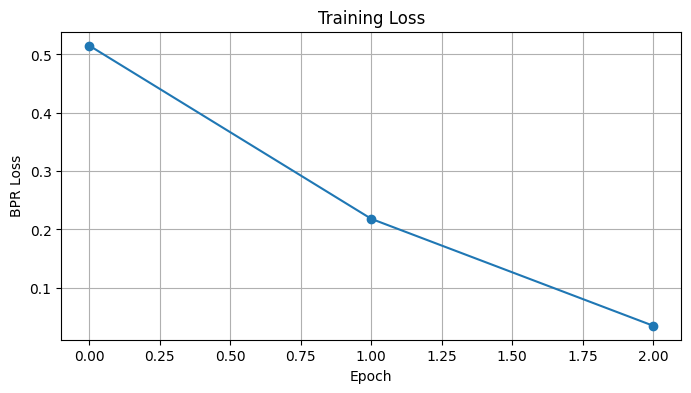

In [139]:
# [Cell 6] 学習ループの実装

def train_model(model, df_interactions, epochs=5, batch_size=128, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # データを時間順にソート（重要）
    df_sorted = df_interactions.sort_values('timestamp').reset_index(drop=True)
    
    # 学習経過記録用
    loss_history = []
    
    print("Start Training...")
    
    for epoch in range(epochs):
        model.init_memory() # エポックごとにメモリ（状態）はリセットすべきか？
        # 一般的には、時系列データの場合、前のエポックの最終状態を引き継ぐか、
        # あるいはゼロから再計算する。ここでは独立性を保つためリセットする。
        
        epoch_loss = 0
        num_batches = int(np.ceil(len(df_sorted) / batch_size))
        
        # 時間順にバッチを取り出す（Shuffle=False）
        for b in tqdm(range(num_batches), desc=f"Epoch {epoch+1}"):
            start_idx = b * batch_size
            end_idx = min((b + 1) * batch_size, len(df_sorted))
            batch_df = df_sorted.iloc[start_idx:end_idx]
            
            # データ準備
            u_ids = torch.tensor(batch_df['user_id'].values, dtype=torch.long).to(device)
            i_ids = torch.tensor(batch_df['item_id'].values, dtype=torch.long).to(device)
            ts = torch.tensor(batch_df['t_norm'].values, dtype=torch.float32).to(device)
            feats = batch_df['feature'].values # リストのまま渡して内部で変換
            
            optimizer.zero_grad()
            
            loss, _, _ = model(u_ids, i_ids, ts, feats)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")
        
    return loss_history

# モデルのインスタンス化と学習実行
hidden_dim = 64
feature_dim = 16 # データ生成時に指定した次元数
ode_func = ODEFunc(hidden_dim).to(device)
gnj_ode = GraphNeuralJumpODE(
    num_users=generator.num_users,
    num_items=generator.num_items,
    hidden_dim=hidden_dim,
    feature_dim=feature_dim,
    ode_func=ode_func
).to(device)

losses = train_model(gnj_ode, df_interactions, epochs=3, batch_size=256)

# 学習曲線のプロット
plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.grid(True)
plt.show()

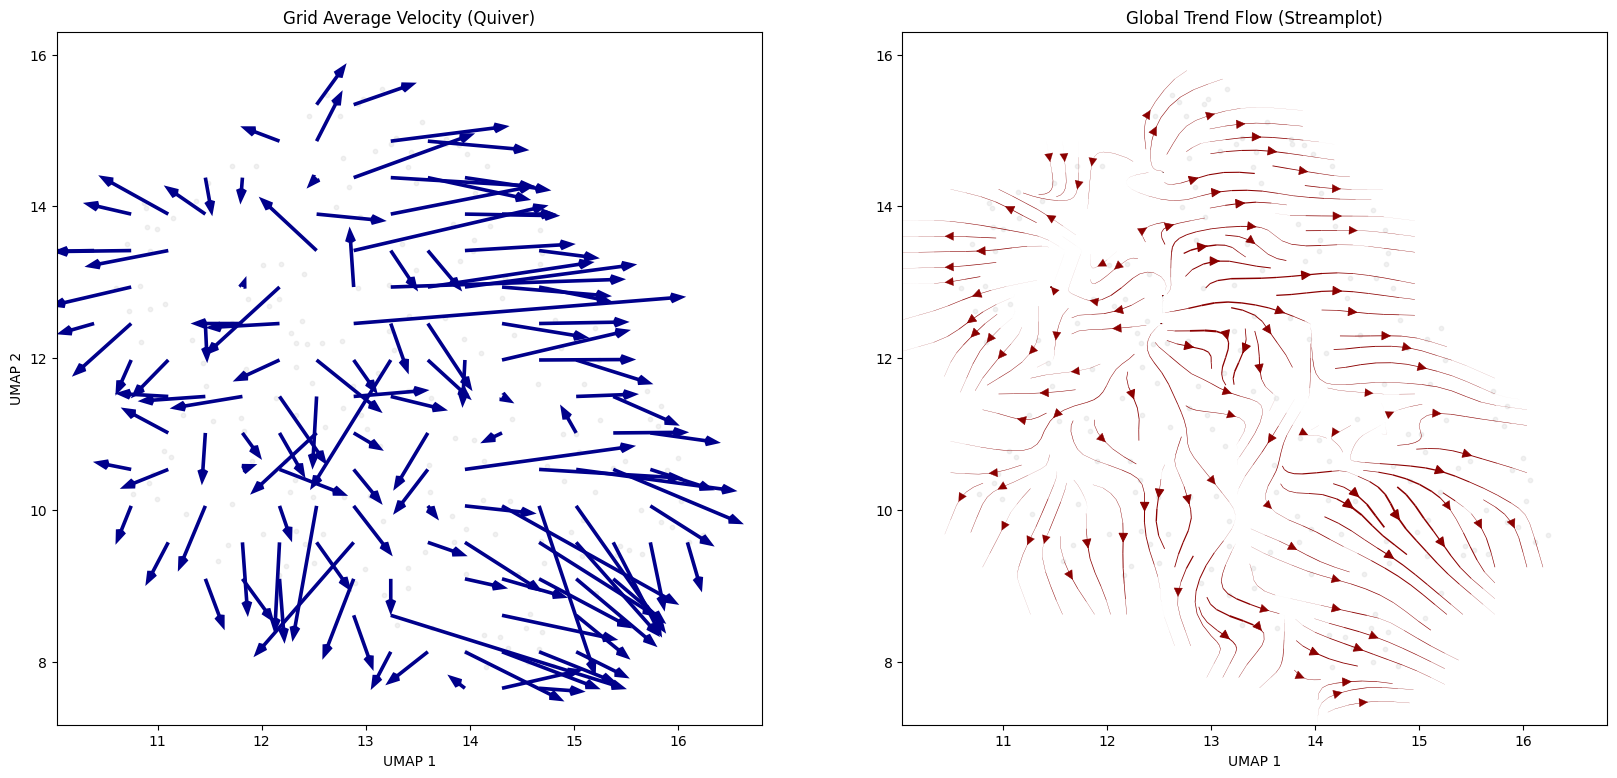

In [148]:
# [Cell 8] グリッド平均による流体風可視化

def visualize_grid_velocity(model, resolution=20, dt=1.0):
    model.eval()
    
    # --- 1. データ準備（前回と同じ） ---
    with torch.no_grad():
        z_users = model.user_memory.cpu().numpy()
        z_tensor = model.user_memory
        velocity_tensor = model.ode_func(torch.tensor(0.0).to(device), z_tensor)
        velocities = velocity_tensor.cpu().numpy()
        
        # 未来位置と移動ベクトル
        z_future = z_users + (velocities * dt)

    # UMAP投影
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
    emb_curr = reducer.fit_transform(z_users)
    emb_fut = reducer.transform(z_future)
    delta_emb = emb_fut - emb_curr # 個々の2D速度ベクトル

    # --- 2. グリッドの作成 ---
    x_min, x_max = emb_curr[:, 0].min(), emb_curr[:, 0].max()
    y_min, y_max = emb_curr[:, 1].min(), emb_curr[:, 1].max()
    
    # マージンを追加
    margin_x = (x_max - x_min) * 0.1
    margin_y = (y_max - y_min) * 0.1
    
    # グリッドポイントの定義
    xi = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    yi = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(xi, yi)
    
    # グリッドごとの平均ベクトルを格納する配列
    U = np.zeros_like(X) # x方向成分
    V = np.zeros_like(Y) # y方向成分
    C = np.zeros_like(X) # カウント（そのマスに何人いるか）

    # --- 3. グリッドごとの平均計算 ---
    # 各点がどのグリッドセルに属するか計算
    # np.digitize を使うと高速ですが、わかりやすくループで処理
    
    # グリッドの幅
    dx = xi[1] - xi[0]
    dy = yi[1] - yi[0]
    
    for i in range(len(emb_curr)):
        px, py = emb_curr[i]
        vx, vy = delta_emb[i]
        
        # インデックスの特定
        idx_x = int((px - (x_min - margin_x)) / dx)
        idx_y = int((py - (y_min - margin_y)) / dy)
        
        # 範囲内であれば加算
        if 0 <= idx_x < resolution and 0 <= idx_y < resolution:
            U[idx_y, idx_x] += vx
            V[idx_y, idx_x] += vy
            C[idx_y, idx_x] += 1
            
    # 平均化（0除算回避）
    mask = C > 0
    U[mask] /= C[mask]
    V[mask] /= C[mask]
    
    # --- 4. 可視化 (Streamplot & Quiver) ---
    fig, ax = plt.subplots(1, 2, figsize=(20, 9))
    
    # 背景の散布図（薄く）
    for a in ax:
        a.scatter(emb_curr[:,0], emb_curr[:,1], c='lightgray', alpha=0.3, s=10)
        a.set_xlim(x_min - margin_x, x_max + margin_x)
        a.set_ylim(y_min - margin_y, y_max + margin_y)
    
    # 左：グリッドベクトル場 (Quiver)
    # ユーザーが存在する場所だけ矢印を表示
    ax[0].quiver(X[mask], Y[mask], U[mask], V[mask], 
                 color='darkblue', angles='xy', scale_units='xy', scale=0.8, 
                 headwidth=3, headlength=4)
    ax[0].set_title("Grid Average Velocity (Quiver)")
    ax[0].set_xlabel("UMAP 1")
    ax[0].set_ylabel("UMAP 2")
    
    # 右：流線図 (Streamplot)
    # 全体的な「流れ」として可視化（データがない場所は補間されるため注意が必要だが、トレンドは見やすい）
    # streamplotはグリッドが等間隔である必要がある
    speed = np.sqrt(U**2 + V**2)
    lw = 2 * speed / speed.max() # 速度が速いところは太く
    
    ax[1].streamplot(X, Y, U, V, color='darkred', density=1.5, linewidth=lw, arrowsize=1.5)
    ax[1].set_title("Global Trend Flow (Streamplot)")
    ax[1].set_xlabel("UMAP 1")
    
    plt.show()

# 実行
visualize_grid_velocity(gnj_ode, resolution=20, dt=0.1)